# Task 4 — Forecasting Access and Usage, 2025–2027
Ethiopia Financial Inclusion Forecasting

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
from data_loader import load_unified_data, load_reference_codes, validate_against_reference, split_by_record_type, get_indicator_series
df = load_unified_data()
ref = load_reference_codes()
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,parent_id,relationship_type,impact_direction,impact_magnitude,magnitude_estimate_pct,lag_months,evidence_basis,original_text,collected_by,collection_date,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN


In [2]:
import sys; sys.path.insert(0, "../src")
from forecasting import build_forecast_table, progress_to_target, fit_trend
import matplotlib.pyplot as plt

## Approach
Given only 5 Findex survey points, two layers are combined:
1. **Baseline trend** — OLS regression of the indicator on survey year.
2. **Event-augmented** — baseline + the *incremental* event effect accrued since the last observation (not the full cumulative effect, which would double-count history already baked into the trend fit).

Three scenarios scale the event contribution: pessimistic (0.5x), base (1.0x), optimistic (1.5x). Confidence intervals widen with forecast horizon.

## Forecast table

In [3]:
forecast = build_forecast_table(df)
forecast

,indicator_code,year,scenario,trend_only,event_contribution,forecast,ci_low,ci_high,trend_is_single_point_fallback
0,ACC_OWNERSHIP,2025,pessimistic,54.24,0.19,54.43,52.93,55.93,False
1,ACC_OWNERSHIP,2025,base,54.24,0.37,54.61,53.11,56.11,False
2,ACC_OWNERSHIP,2025,optimistic,54.24,0.56,54.80,53.30,56.30,False
3,ACC_OWNERSHIP,2026,pessimistic,56.95,0.76,57.71,54.71,60.71,False
4,ACC_OWNERSHIP,2026,base,56.95,1.52,58.47,55.47,61.47,False
5,ACC_OWNERSHIP,2026,optimistic,56.95,2.28,59.23,56.23,62.23,False
6,ACC_OWNERSHIP,2027,pessimistic,59.66,0.85,60.51,56.01,65.01,False
7,ACC_OWNERSHIP,2027,base,59.66,1.70,61.36,56.86,65.86,False
8,ACC_OWNERSHIP,2027,optimistic,59.66,2.55,62.21,57.71,66.71,False
9,USG_DIGITAL_PAYMENT,2025,pessimistic,35.00,0.92,35.92,32.92,38.92,True


## Access (Account Ownership) — forecast with scenarios

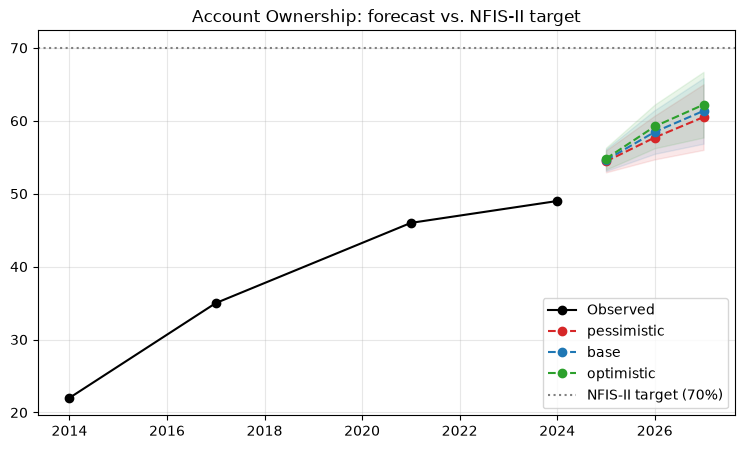

In [4]:
acc_fc = forecast[forecast["indicator_code"]=="ACC_OWNERSHIP"]
hist = get_indicator_series(df, "ACC_OWNERSHIP")

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(hist["observation_date"].dt.year, hist["value_numeric"], "ko-", label="Observed")
for scen, color in [("pessimistic","tab:red"),("base","tab:blue"),("optimistic","tab:green")]:
    s = acc_fc[acc_fc["scenario"]==scen]
    ax.plot(s["year"], s["forecast"], "o--", color=color, label=scen)
    ax.fill_between(s["year"], s["ci_low"], s["ci_high"], color=color, alpha=0.1)
ax.axhline(70, color="grey", linestyle=":", label="NFIS-II target (70%)")
ax.set_title("Account Ownership: forecast vs. NFIS-II target")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Usage (Digital Payment Adoption) — forecast with scenarios
**Caveat**: this indicator has only one historical observation (35%, 2024), added during enrichment — see `../data_enrichment_log.md`. There is no fitted trend, only a flat-line baseline, and the confidence interval is widened accordingly (`trend_is_single_point_fallback = True`).

In [5]:
usg_fc = forecast[forecast["indicator_code"]=="USG_DIGITAL_PAYMENT"]
print("Single-point fallback:", usg_fc["trend_is_single_point_fallback"].iloc[0])
usg_fc

Single-point fallback: True


,indicator_code,year,scenario,trend_only,event_contribution,forecast,ci_low,ci_high,trend_is_single_point_fallback
9,USG_DIGITAL_PAYMENT,2025,pessimistic,35.0,0.92,35.92,32.92,38.92,True
10,USG_DIGITAL_PAYMENT,2025,base,35.0,1.85,36.85,33.85,39.85,True
11,USG_DIGITAL_PAYMENT,2025,optimistic,35.0,2.77,37.78,34.78,40.78,True
12,USG_DIGITAL_PAYMENT,2026,pessimistic,35.0,1.87,36.87,30.87,42.87,True
13,USG_DIGITAL_PAYMENT,2026,base,35.0,3.74,38.74,32.74,44.74,True
14,USG_DIGITAL_PAYMENT,2026,optimistic,35.0,5.61,40.61,34.61,46.61,True
15,USG_DIGITAL_PAYMENT,2027,pessimistic,35.0,2.38,37.38,28.38,46.38,True
16,USG_DIGITAL_PAYMENT,2027,base,35.0,4.76,39.76,30.76,48.76,True
17,USG_DIGITAL_PAYMENT,2027,optimistic,35.0,7.14,42.14,33.14,51.14,True


## Progress toward the NFIS-II 70% Access target

In [6]:
progress_to_target(df, forecast)

,target_2025,base_forecast_2025,gap_pp
0,70.0,54.61,15.39


## Interpretation
- **Base-case 2025 Access** is forecast at ~54.6%, a **~15pp gap** to the NFIS-II 70% target — the trend deceleration seen in Task 2 does not close on its own without additional intervention.
- **Largest-impact events for 2026-2027** (Fayda digital ID, M-Pesa/EthSwitch interoperability, EthioPay) are all `literature`-based estimates with no Ethiopian post-period validation yet — this is where the optimistic/pessimistic scenario spread matters most, and where new 2025/2026 Findex or EthSwitch data would most improve the model.
- **Key uncertainty**: the Usage forecast rests on a single historical data point. Sourcing an earlier digital-payment adoption figure is the single highest-value next step for improving this model.